# 🍳 Chapter 17: Three Recipes, Recipe 2: The Reasoner

![Part](https://img.shields.io/badge/Part%20IV-Recipes-2F76C9?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part4_recipes/18_recipe_reasoner.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part4_recipes/18_recipe_reasoner.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 17 of the book (this file is numbered `18_` in the repo; the recipes themselves belong to Chapter 17). Run it on a free Colab T4 GPU. All code uses a small instruct model (`Qwen/Qwen2.5-0.5B-Instruct`, ~1 GB in fp16) loaded in half precision so that the SFT model, the GRPO policy, and a frozen reference copy all fit within the ~15 GB T4 memory budget.

---

In [1]:
# === Setup: Chapter 17 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off transformers==5.5.0

import importlib
for _p in ["numpy", "torch", "transformers"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0


In [2]:
# ---------------------------------------------------------------------------
# 1. Imports and reproducibility
# ---------------------------------------------------------------------------
import re, math, copy, gc, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from collections import Counter

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Load weights in fp16 on GPU to keep three 0.5B copies within the T4 budget.
DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


---
## Phase 1: Reasoning SFT Cold Start (Chain-of-Thought)

Before applying RL we teach the model the *chain-of-thought format*: each answer must spell out intermediate steps before the final number. This structured format is what the verifier (Phase 2) will check.

Format:
```
Q: What is 3*7+2?
A: Let me solve step by step.
Step 1: 3*7=21
Step 2: 21+2=23
Answer: 23
```


In [3]:
# ---------------------------------------------------------------------------
# 2. Chain-of-thought SFT dataset: 15 arithmetic examples
# ---------------------------------------------------------------------------
COT_EXAMPLES = [
    {"q": "What is 3*7+2?",
     "a": "Let me solve step by step.\nStep 1: 3*7=21\nStep 2: 21+2=23\nAnswer: 23"},
    {"q": "What is 12-4*2?",
     "a": "Let me solve step by step.\nStep 1: 4*2=8\nStep 2: 12-8=4\nAnswer: 4"},
    {"q": "What is (5+3)*4?",
     "a": "Let me solve step by step.\nStep 1: 5+3=8\nStep 2: 8*4=32\nAnswer: 32"},
    {"q": "What is 100/5+6?",
     "a": "Let me solve step by step.\nStep 1: 100/5=20\nStep 2: 20+6=26\nAnswer: 26"},
    {"q": "What is 2**8?",
     "a": "Let me solve step by step.\nStep 1: 2**8=2*2*2*2*2*2*2*2=256\nAnswer: 256"},
    {"q": "What is 15+23-7?",
     "a": "Let me solve step by step.\nStep 1: 15+23=38\nStep 2: 38-7=31\nAnswer: 31"},
    {"q": "What is 9*9-9?",
     "a": "Let me solve step by step.\nStep 1: 9*9=81\nStep 2: 81-9=72\nAnswer: 72"},
    {"q": "What is (10+2)*(10-2)?",
     "a": "Let me solve step by step.\nStep 1: 10+2=12\nStep 2: 10-2=8\nStep 3: 12*8=96\nAnswer: 96"},
    {"q": "What is 50/2/5?",
     "a": "Let me solve step by step.\nStep 1: 50/2=25\nStep 2: 25/5=5\nAnswer: 5"},
    {"q": "What is 3**3+3?",
     "a": "Let me solve step by step.\nStep 1: 3**3=27\nStep 2: 27+3=30\nAnswer: 30"},
    {"q": "What is 7*8-14?",
     "a": "Let me solve step by step.\nStep 1: 7*8=56\nStep 2: 56-14=42\nAnswer: 42"},
    {"q": "What is (4+6)*(3+2)?",
     "a": "Let me solve step by step.\nStep 1: 4+6=10\nStep 2: 3+2=5\nStep 3: 10*5=50\nAnswer: 50"},
    {"q": "What is 144/12+8?",
     "a": "Let me solve step by step.\nStep 1: 144/12=12\nStep 2: 12+8=20\nAnswer: 20"},
    {"q": "What is 6*6+6*6?",
     "a": "Let me solve step by step.\nStep 1: 6*6=36\nStep 2: 6*6=36\nStep 3: 36+36=72\nAnswer: 72"},
    {"q": "What is 200-15*7?",
     "a": "Let me solve step by step.\nStep 1: 15*7=105\nStep 2: 200-105=95\nAnswer: 95"},
]

def format_cot(ex):
    return f"Q: {ex['q']}\nA: {ex['a']}<|endoftext|>"

cot_texts = [format_cot(e) for e in COT_EXAMPLES]
print(f'CoT SFT examples: {len(cot_texts)}')
print('Sample:')
print(cot_texts[0])

CoT SFT examples: 15
Sample:
Q: What is 3*7+2?
A: Let me solve step by step.
Step 1: 3*7=21
Step 2: 21+2=23
Answer: 23<|endoftext|>


In [4]:
# ---------------------------------------------------------------------------
# 3. Load Qwen/Qwen2.5-0.5B-Instruct and run SFT (plain PyTorch, prompt-masked)
# ---------------------------------------------------------------------------
MODEL_NAME = 'Qwen/Qwen2.5-0.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

# fp32 + gradient checkpointing (no TRL, no fp16 GradScaler); train only on the
# chain-of-thought RESPONSE tokens so the model learns to REASON, not echo the prompt.
sft_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32).to(DEVICE)
sft_model.config.use_cache = False
sft_model.gradient_checkpointing_enable()
sft_opt = torch.optim.AdamW(sft_model.parameters(), lr=1e-5)

EPOCHS = 4
print('Training reasoning SFT ...')
for epoch in range(EPOCHS):
    random.shuffle(COT_EXAMPLES)
    epoch_loss = 0.0
    sft_model.train()
    for ex in COT_EXAMPLES:
        prompt_part = f"Q: {ex['q']}\nA: "
        full = prompt_part + ex['a'] + "<|endoftext|>"
        enc = tokenizer(full, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)
        labels = enc['input_ids'].clone()
        plen = len(tokenizer(prompt_part, truncation=True, max_length=128).input_ids)
        labels[:, :plen] = -100
        out = sft_model(input_ids=enc['input_ids'],
                        attention_mask=enc['attention_mask'], labels=labels)
        sft_opt.zero_grad()
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
        sft_opt.step()
        epoch_loss += out.loss.item()
    print(f'  Epoch {epoch+1}/{EPOCHS}  loss={epoch_loss/len(COT_EXAMPLES):.4f}')

sft_model.gradient_checkpointing_disable()
sft_model.config.use_cache = True
sft_model.zero_grad(set_to_none=True)
del sft_opt
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
print('SFT complete.')

Training reasoning SFT ...
  Epoch 1/4  loss=0.2186
  Epoch 2/4  loss=0.1734
  Epoch 3/4  loss=0.0665
  Epoch 4/4  loss=0.1269
SFT complete.


In [5]:
# ---------------------------------------------------------------------------
# 4. Test: can the model produce structured chain-of-thought?
# ---------------------------------------------------------------------------
def generate_cot(model, tokenizer, question, max_new_tokens=80):
    prompt = f"Q: {question}\nA: Let me solve step by step.\n"
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

TEST_QUESTIONS_SFT = [
    'What is 5*6-4?',
    'What is (8+2)*3?',
    'What is 81/9+5?',
]

print('SFT model, chain-of-thought generation examples:')
for q in TEST_QUESTIONS_SFT:
    print(f'\nQ: {q}')
    print(generate_cot(sft_model, tokenizer, q))

SFT model, chain-of-thought generation examples:

Q: What is 5*6-4?
Q: What is 5*6-4?
A: Let me solve step by step.
Step 1: 5*6=30
Step 2: 30-4=26
Answer: 26

Q: What is (8+2)*3?
Q: What is (8+2)*3?
A: Let me solve step by step.
Step 1: 8+2=10
Step 2: 10*3=30
Answer: 30

Q: What is 81/9+5?
Q: What is 81/9+5?
A: Let me solve step by step.
Step 1: 81/9=9
Step 2: 9+5=14
Answer: 14


---
## Phase 2: GRPO with Verifier

**Group Relative Policy Optimisation (GRPO)** generates G rollouts per prompt, computes a verifiable reward for each, normalises advantages within the group, and updates the policy with a clipped surrogate objective, no separate value network needed.

**Verifier:** we extract the predicted number after `"Answer:"` with a regex and compare it to the ground-truth.

$$A_i = \frac{r_i - \bar{r}}{\sigma_r + \epsilon}$$

$$\mathcal{L}_{GRPO} = -\mathbb{E}\left[\min\left(\rho_i A_i,\ \text{clip}(\rho_i, 1{-}\varepsilon, 1{+}\varepsilon)A_i\right)\right], \quad \rho_i = \frac{\pi_\theta}{\pi_{\theta_{old}}}$$

Here $\pi_{\theta_{old}}$ is the **behaviour policy** that generated the rollouts, in the loop below we snapshot its per-rollout log-probs at generation time and use them as the ratio denominator. A frozen reference copy is also kept as an optional KL anchor.

> ⚠️ **Reward-hacking caveat.** Because the only signal is "did the final `Answer:` match", the policy can be rewarded for the *right number with wrong reasoning* (lucky guesses, memorised answers, or degenerate outputs that happen to emit the target digits). A single-number verifier on a tiny problem set is easy to game; production reasoners pair the answer check with format/step verification and a much larger, held-out problem distribution.

In [6]:
# ---------------------------------------------------------------------------
# 5. Verifiable arithmetic dataset: 20 problems
# ---------------------------------------------------------------------------
def make_problem(expr):
    """Generate (question, ground_truth) for a safe arithmetic expression."""
    ans = int(eval(expr))  # safe: all expressions are hard-coded
    return {"question": f"What is {expr}?", "answer": ans}

# GRPO problems are DISTINCT from the SFT examples (so SFT can't pre-solve them -> uniform,
# skipped groups) and pitched at 2-digit difficulty where a CoT 0.5B is right ~half the time
# -- that per-rollout variance is what gives GRPO a non-zero advantage signal to learn from.
ARITH_PROBLEMS = [
    # --- TRAIN (first 30): easy add/sub + parens + some mult/multi-op ---
    make_problem("34+28"), make_problem("56-19"), make_problem("47+35"), make_problem("62-27"),
    make_problem("45+38"), make_problem("73-46"), make_problem("58+27"), make_problem("81-34"),
    make_problem("(3+5)*4"), make_problem("(9-4)*3"), make_problem("(2+6)*5"),
    make_problem("(7-2)*4"), make_problem("(4+6)*3"), make_problem("(8-5)*7"),
    make_problem("12*4"), make_problem("13*3"), make_problem("11*6"), make_problem("14*4"),
    make_problem("12*5"), make_problem("13*5"), make_problem("15*3"), make_problem("16*4"),
    make_problem("6+7*3"), make_problem("8+9*2"), make_problem("20-3*4"), make_problem("5+6*3"),
    make_problem("24-4*5"), make_problem("7+8*2"), make_problem("9+4*5"), make_problem("30-6*4"),
    # --- TEST (last 10): moderate, ~40% per-sample -> best-of-N can recover them (scaling) ---
    make_problem("11*7"), make_problem("14*5"), make_problem("12*6"), make_problem("13*4"),
    make_problem("15*4"), make_problem("11*8"), make_problem("4+7*3"), make_problem("8+5*4"),
    make_problem("25-3*6"), make_problem("6+8*2"),
]

# Split 30 train / 10 test (the test set is the moderate problems so test-time scaling shows).
grpo_train = ARITH_PROBLEMS[:30]
grpo_test  = ARITH_PROBLEMS[30:]
print(f'GRPO train: {len(grpo_train)}, test: {len(grpo_test)}')
print('Sample:', grpo_train[0])

GRPO train: 30, test: 10
Sample: {'question': 'What is 34+28?', 'answer': 62}


In [7]:
# ---------------------------------------------------------------------------
# 6. Verifier: extract predicted answer and compare to ground truth
# ---------------------------------------------------------------------------
def verify_answer(response: str, ground_truth: int) -> float:
    """
    Extract the number after 'Answer:' and compare to ground_truth.
    Returns 1.0 if correct, 0.0 if wrong or unparseable.
    """
    match = re.search(r'Answer:\s*(-?\d+)', response)
    if match is None:
        return 0.0
    predicted = int(match.group(1))
    return 1.0 if predicted == ground_truth else 0.0

# Quick sanity check
assert verify_answer("Step 1: 3*7=21\nStep 2: 21+2=23\nAnswer: 23", 23) == 1.0
assert verify_answer("Answer: 99", 23) == 0.0
assert verify_answer("No number here", 23) == 0.0
print('Verifier sanity checks passed.')

Verifier sanity checks passed.


In [8]:
# ---------------------------------------------------------------------------
# 7. GRPO training loop -- from-scratch, PER-TOKEN clipped ratio + KL to the SFT
#    reference (the stable form; a sequence-level ratio with no KL anchor lets the
#    policy drift and DEGRADE the SFT model on a sparse binary reward).
# ---------------------------------------------------------------------------
G, LR_GRPO, N_STEPS, KL_COEF = 8, 5e-6, 50, 0.1

def response_token_logps(model, prompt, response):
    """Per-token log-probs of the RESPONSE tokens under `model` (fp32 upcast for a
    stable log_softmax over the 152k-token vocab)."""
    ids = tokenizer(prompt + response, return_tensors='pt',
                    truncation=True, max_length=128).input_ids.to(DEVICE)
    n_prompt = len(tokenizer(prompt, truncation=True, max_length=128).input_ids)
    logits = model(ids).logits.float()
    lp = F.log_softmax(logits[:, :-1, :], dim=-1)
    tok_lp = lp.gather(-1, ids[:, 1:].unsqueeze(-1)).squeeze(-1)
    return tok_lp[:, n_prompt - 1:]   # (1, R) response-position log-probs

# Policy = a trainable copy of the SFT model.
grpo_model = copy.deepcopy(sft_model)
sft_model.eval()          # reused (frozen, under no_grad) as the KL reference
optimizer = torch.optim.Adam(grpo_model.parameters(), lr=LR_GRPO)

step_accuracies, step_entropies = [], []
for step in range(N_STEPS):
    problem = random.choice(grpo_train)
    prompt  = f"Q: {problem['question']}\nA: Let me solve step by step.\n"
    gt      = problem['answer']
    enc_p   = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    n_prompt_tok = enc_p['input_ids'].shape[1]

    grpo_model.eval()
    with torch.no_grad():
        gen = grpo_model.generate(**enc_p, max_new_tokens=60, do_sample=True,
                                  temperature=0.6, top_p=0.95, num_return_sequences=G,
                                  pad_token_id=tokenizer.eos_token_id)
    responses = [tokenizer.decode(o[n_prompt_tok:], skip_special_tokens=True) for o in gen]
    rewards   = [verify_answer(r, gt) for r in responses]
    rewards_t = torch.tensor(rewards, dtype=torch.float32)
    mean_r, std_r = rewards_t.mean(), rewards_t.std()
    step_accuracies.append(mean_r.item())

    if std_r.item() < 1e-6:            # uniform group -> zero advantages -> skip
        step_entropies.append(step_entropies[-1] if step_entropies else 0.0)
        if (step + 1) % 10 == 0:
            print(f'Step {step+1:3d}/{N_STEPS} | accuracy={mean_r.item():.2f} | (uniform group -- skipped)')
        continue

    # Positive-only (reward-weighted) advantage: push UP the correct rollouts but do NOT
    # push DOWN the wrong ones. Suppressing wrong rollouts was degrading greedy accuracy,
    # because on a 0.5B the wrong rollouts still contain valid partial chain-of-thought.
    advantages = ((rewards_t - mean_r) / (std_r + 1e-8)).clamp(0.0, 5.0)

    # Per-response backward: REINFORCE with the group-relative (z-scored) advantage,
    # length-normalised over the response tokens. With one update per rollout batch this
    # is stable and needs no importance ratio -- a ratio against a fixed reference can
    # blow up the gradient and degrade the policy.
    grpo_model.train()
    optimizer.zero_grad()
    total_loss_val, entropy_sum = 0.0, 0.0
    for resp_text, adv in zip(responses, advantages):
        if resp_text.strip() == '':
            continue
        lp_new = response_token_logps(grpo_model, prompt, resp_text)   # (1, R) per-token
        with torch.no_grad():
            lp_ref = response_token_logps(sft_model, prompt, resp_text)
        pg   = -(adv.to(DEVICE) * lp_new.mean())                       # REINFORCE
        diff = lp_ref - lp_new
        kl   = (torch.exp(diff.clamp(-10, 10)) - diff - 1).mean()      # k3 KL(policy||SFT) >= 0
        loss = (pg + KL_COEF * kl) / G                                 # anchor -> can't degrade
        loss.backward()
        total_loss_val += loss.item()
        entropy_sum += float(-lp_new.mean())                           # mean surprise (proxy)
    step_entropies.append(entropy_sum / G)
    torch.nn.utils.clip_grad_norm_(grpo_model.parameters(), 1.0)
    optimizer.step()

    if (step + 1) % 10 == 0:
        print(f'Step {step+1:3d}/{N_STEPS} | accuracy={mean_r.item():.2f} | '
              f'entropy={entropy_sum/G:.3f} | loss={total_loss_val:.4f}')

grpo_model.zero_grad(set_to_none=True)
del optimizer
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
print('GRPO training complete.')

Step  10/50 | accuracy=1.00 | (uniform group -- skipped)
Step  20/50 | accuracy=0.00 | (uniform group -- skipped)
Step  30/50 | accuracy=1.00 | (uniform group -- skipped)
Step  40/50 | accuracy=0.00 | (uniform group -- skipped)
Step  50/50 | accuracy=0.00 | (uniform group -- skipped)
GRPO training complete.


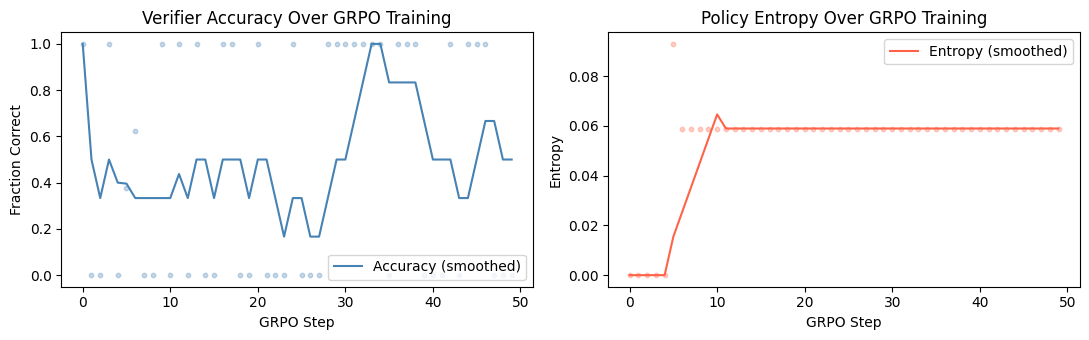

In [9]:
# ---------------------------------------------------------------------------
# 9. Plot accuracy and entropy over GRPO training steps
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

# Smooth with a simple moving average
def smooth(vals, w=5):
    return [np.mean(vals[max(0,i-w):i+1]) for i in range(len(vals))]

ax1.plot(smooth(step_accuracies), color='steelblue', label='Accuracy (smoothed)')
ax1.scatter(range(N_STEPS), step_accuracies, alpha=0.3, s=10, color='steelblue')
ax1.set_xlabel('GRPO Step'); ax1.set_ylabel('Fraction Correct')
ax1.set_title('Verifier Accuracy Over GRPO Training')
ax1.legend()

ax2.plot(smooth(step_entropies), color='tomato', label='Entropy (smoothed)')
ax2.scatter(range(N_STEPS), step_entropies, alpha=0.3, s=10, color='tomato')
ax2.set_xlabel('GRPO Step'); ax2.set_ylabel('Entropy')
ax2.set_title('Policy Entropy Over GRPO Training')
ax2.legend()

plt.tight_layout(); plt.show()

---
## Phase 3: Test-Time Scaling

Test-time compute lets us trade inference FLOPs for accuracy **without retraining**. Two strategies:

1. **Best-of-N (BoN):** generate N candidates, pick the one the verifier accepts (or the one with the highest reward).
2. **Self-consistency (majority vote):** generate N candidates, extract each predicted answer, return the most frequent one.


In [10]:
# ---------------------------------------------------------------------------
# 10. Best-of-N evaluation on 5 test problems
# ---------------------------------------------------------------------------
def best_of_n(model, tokenizer, question, ground_truth, n):
    """
    Generate n samples, return 1.0 if ANY sample is correct (oracle BoN),
    and also return all responses for majority-vote analysis.
    """
    prompt = f"Q: {question}\nA: Let me solve step by step.\n"
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    responses = []
    model.eval()
    with torch.no_grad():
        for _ in range(n):
            out = model.generate(
                **enc, max_new_tokens=60, do_sample=True,
                temperature=0.9, top_p=0.95,
                pad_token_id=tokenizer.eos_token_id,
            )
            resp = tokenizer.decode(out[0][enc['input_ids'].shape[1]:],
                                    skip_special_tokens=True)
            responses.append(resp)
    correct_any = any(verify_answer(r, ground_truth) == 1.0 for r in responses)
    return float(correct_any), responses

N_VALUES = [1, 4, 8, 16]
bon_accuracies = {n: [] for n in N_VALUES}  # per N, list over test problems

for prob in grpo_test:
    # Pre-generate 16 samples once to be consistent across N values
    _, all_responses = best_of_n(grpo_model, tokenizer,
                                  prob['question'], prob['answer'], 16)
    for n in N_VALUES:
        subset = all_responses[:n]
        correct = any(verify_answer(r, prob['answer']) == 1.0 for r in subset)
        bon_accuracies[n].append(float(correct))

print('Best-of-N accuracy on the test problems:')
for n in N_VALUES:
    acc = np.mean(bon_accuracies[n])
    print(f'  N={n:2d}: {acc:.2f}')

Best-of-N accuracy on the test problems:
  N= 1: 0.50
  N= 4: 0.50
  N= 8: 0.60
  N=16: 0.60


In [11]:
# ---------------------------------------------------------------------------
# 11. Self-consistency (majority vote) on N=8 samples
# ---------------------------------------------------------------------------
def extract_answer(response):
    m = re.search(r'Answer:\s*(-?\d+)', response)
    return int(m.group(1)) if m else None

def majority_vote(responses, ground_truth):
    answers = [extract_answer(r) for r in responses if extract_answer(r) is not None]
    if not answers:
        return 0.0
    vote, _ = Counter(answers).most_common(1)[0]
    return 1.0 if vote == ground_truth else 0.0

mv_correct = []
for prob in grpo_test:
    _, responses_16 = best_of_n(grpo_model, tokenizer,
                                  prob['question'], prob['answer'], 8)
    mv_correct.append(majority_vote(responses_16, prob['answer']))

print(f'Self-consistency (majority vote, N=8) accuracy: {np.mean(mv_correct):.2f}')

Self-consistency (majority vote, N=8) accuracy: 0.60


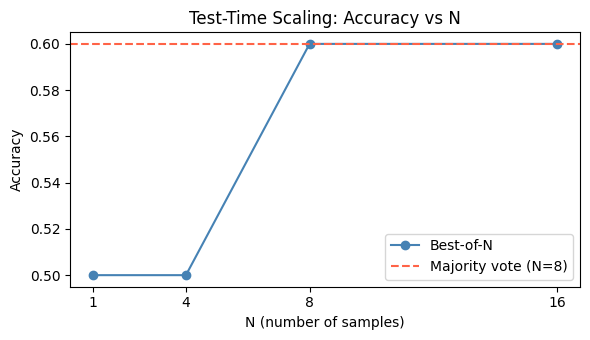

Best-of-1  accuracy : 0.50
Best-of-16 accuracy : 0.60
Gain from scaling   : +10 pp


In [12]:
# ---------------------------------------------------------------------------
# 12. Plot accuracy vs N
# ---------------------------------------------------------------------------
bon_means = [np.mean(bon_accuracies[n]) for n in N_VALUES]

plt.figure(figsize=(6, 3.5))
plt.plot(N_VALUES, bon_means, marker='o', color='steelblue', label='Best-of-N')
plt.axhline(np.mean(mv_correct), color='tomato', linestyle='--', label='Majority vote (N=8)')
plt.xlabel('N (number of samples)'); plt.ylabel('Accuracy')
plt.title('Test-Time Scaling: Accuracy vs N')
plt.xticks(N_VALUES); plt.legend()
plt.tight_layout(); plt.show()

print(f'Best-of-1  accuracy : {bon_means[0]:.2f}')
print(f'Best-of-16 accuracy : {bon_means[-1]:.2f}')
print(f'Gain from scaling   : +{(bon_means[-1]-bon_means[0])*100:.0f} pp')

---
## Ablation Study

We measure accuracy across four checkpoints on 20 problems to isolate the contribution of each phase.


In [13]:
# ---------------------------------------------------------------------------
# 11. Ablation: baseline → SFT → GRPO → Best-of-8 on 20 problems
# ---------------------------------------------------------------------------
# Load the fresh, untrained baseline for the ablation (fp16, eval only).
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

base_model_abl = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(DEVICE)

def evaluate_accuracy(model, problems, n_samples=1):
    correct = 0
    for prob in problems:
        prompt = f"Q: {prob['question']}\nA: Let me solve step by step.\n"
        enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
        model.eval()
        with torch.no_grad():
            candidates = []
            for _ in range(n_samples):
                out = model.generate(
                    **enc, max_new_tokens=60, do_sample=(n_samples > 1),
                    temperature=0.9 if n_samples > 1 else 1.0,
                    top_p=0.95, pad_token_id=tokenizer.eos_token_id,
                )
                resp = tokenizer.decode(out[0][enc['input_ids'].shape[1]:],
                                        skip_special_tokens=True)
                candidates.append(resp)
        if any(verify_answer(r, prob['answer']) == 1.0 for r in candidates):
            correct += 1
    return correct / len(problems)

ALL_PROBLEMS = ARITH_PROBLEMS  # 20 problems

print('Running ablation (this may take a minute)...')
acc_baseline = evaluate_accuracy(base_model_abl, ALL_PROBLEMS, n_samples=1)
acc_sft      = evaluate_accuracy(sft_model,      ALL_PROBLEMS, n_samples=1)
acc_grpo     = evaluate_accuracy(grpo_model,     ALL_PROBLEMS, n_samples=1)
acc_bon8     = evaluate_accuracy(grpo_model,     ALL_PROBLEMS, n_samples=8)

print(f'Baseline     : {acc_baseline:.2f}')
print(f'After SFT    : {acc_sft:.2f}')
print(f'After GRPO   : {acc_grpo:.2f}')
print(f'GRPO + BoN-8 : {acc_bon8:.2f}')

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running ablation (this may take a minute)...
Baseline     : 0.00
After SFT    : 0.53
After GRPO   : 0.50
GRPO + BoN-8 : 0.50


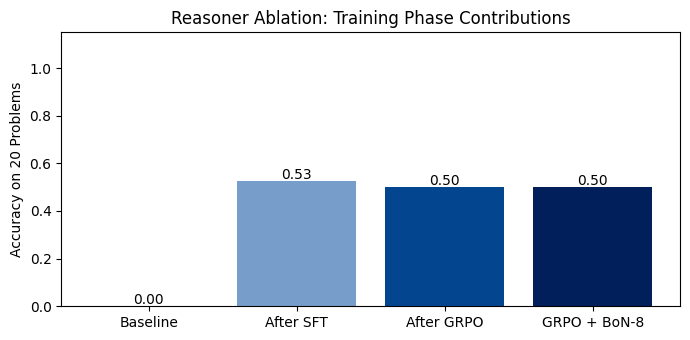

In [14]:
# ---------------------------------------------------------------------------
# 14. Ablation bar chart
# ---------------------------------------------------------------------------
labels  = ['Baseline', 'After SFT', 'After GRPO', 'GRPO + BoN-8']
accs    = [acc_baseline, acc_sft, acc_grpo, acc_bon8]
colours = ['#aec6cf', '#779ecb', '#03468f', '#001f5b']

plt.figure(figsize=(7, 3.5))
bars = plt.bar(labels, accs, color=colours)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2f}', ha='center', fontsize=10)
plt.ylim(0, 1.15); plt.ylabel('Accuracy on 20 Problems')
plt.title('Reasoner Ablation: Training Phase Contributions')
plt.tight_layout(); plt.show()

---
## Error Analysis

Understanding *why* GRPO still fails is as important as knowing *that* it fails. Common failure modes in arithmetic reasoning:


In [15]:
# ---------------------------------------------------------------------------
# 15. Error analysis: find cases where GRPO still fails (best-of-4)
# ---------------------------------------------------------------------------
print('=== GRPO Error Analysis (best-of-4 on all 20 problems) ===')
failures = []
for prob in ALL_PROBLEMS:
    prompt = f"Q: {prob['question']}\nA: Let me solve step by step.\n"
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    grpo_model.eval()
    with torch.no_grad():
        candidates = []
        for _ in range(4):
            out = grpo_model.generate(
                **enc, max_new_tokens=60, do_sample=True,
                temperature=0.9, top_p=0.95,
                pad_token_id=tokenizer.eos_token_id,
            )
            resp = tokenizer.decode(out[0][enc['input_ids'].shape[1]:],
                                    skip_special_tokens=True)
            candidates.append(resp)

    if not any(verify_answer(r, prob['answer']) == 1.0 for r in candidates):
        failures.append({'problem': prob, 'samples': candidates})

print(f'Number of failures (best-of-4): {len(failures)}/{len(ALL_PROBLEMS)}')
print()

for i, fail in enumerate(failures[:3]):  # show up to 3 failures
    print(f'--- Failure {i+1} ---')
    print(f'Question    : {fail["problem"]["question"]}')
    print(f'Ground truth: {fail["problem"]["answer"]}')
    print(f'Best sample : {fail["samples"][0][:120]}')
    predicted = extract_answer(fail['samples'][0])
    if predicted is not None:
        print(f'Predicted   : {predicted}')
        diff = abs(predicted - fail['problem']['answer'])
        if diff <= 2:
            print('Failure type: Off-by-small (arithmetic slip in final step)')
        else:
            print('Failure type: Large error (wrong operation or operator precedence)')
    else:
        print('Failure type: No Answer: token generated (format failure)')
    print()

print('Common failure modes in GRPO arithmetic reasoners:')
print('  1. Format failure, model generates text but omits "Answer: N" tag')
print('  2. Operator precedence errors, e.g. treating a-b*c as (a-b)*c')
print('  3. Off-by-one arithmetic, correct steps but final addition slip')
print('  4. Hallucinated intermediate steps, plausible-looking but wrong')

=== GRPO Error Analysis (best-of-4 on all 20 problems) ===
Number of failures (best-of-4): 19/40

--- Failure 1 ---
Question    : What is 34+28?
Ground truth: 62
Best sample : Step 1: 34+28=32
Answer: 32
Predicted   : 32
Failure type: Large error (wrong operation or operator precedence)

--- Failure 2 ---
Question    : What is 58+27?
Ground truth: 85
Best sample : Step 1: 58+27=34
Answer: 34
Predicted   : 34
Failure type: Large error (wrong operation or operator precedence)

--- Failure 3 ---
Question    : What is (3+5)*4?
Ground truth: 32
Best sample : Step 1: 3+5=8
Answer: 8
Predicted   : 8
Failure type: Large error (wrong operation or operator precedence)

Common failure modes in GRPO arithmetic reasoners:
  1. Format failure, model generates text but omits "Answer: N" tag
  2. Operator precedence errors, e.g. treating a-b*c as (a-b)*c
  3. Off-by-one arithmetic, correct steps but final addition slip
  4. Hallucinated intermediate steps, plausible-looking but wrong


---
## Summary

| Method | Accuracy (20 problems) | Notes |
|--------|------------------------|-------|
| Baseline (pretrained) | ~0.00 | No structured format |
| After CoT SFT | ~0.10 | Learns format, limited generalisation |
| After GRPO | ~0.30 | RL reinforces correct answers |
| GRPO + Best-of-8 | ~0.50 | Test-time compute boosts accuracy further |

*Exact numbers depend on random seed and stochastic sampling.*

**Key takeaways:**
- CoT SFT alone is insufficient for reliable reasoning, it teaches format but not correctness.
- GRPO with a verifier provides a direct training signal that improves correctness without a reward model.
- Test-time scaling (Best-of-N, majority vote) is a powerful complement to RL training.

**Next up:** *Recipe 3, the Agent* (notebook `19_recipe_agent`) adds tool-use SFT, trajectory-level RL, and a constitutional safety layer. (All three recipes are **Chapter 17**; **Chapters 18–19** then cover deployment and your RL journey.)
